In [193]:
#Assignment: Predicting the customer type based on the transaction data (Classification problem) 
#Models:
#1. Logistic Regression
#2. Decision Tree Classifier
#3. Random Forest Classifier  

In [194]:
##Predict the customer tpe based on the transaction data (Classification problem)
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import cross_val_score

from pathlib import Path

In [195]:
path = Path(r'C:/Users/hp/OneDrive/Documents/Software Engineering Course/Year 2 sem 2/Recess/PYTHON LECTURES/TabithaAngelChebet/MachineLearningAssignments/Datasets/ecommerce_bigdata.csv')
try:
    df = pd.read_csv(path, na_values=['', ' ', 'NA', 'N/A', 'None'])
    
except FileNotFoundError:
    print(f"File not found at {path}. Please check the file path and try again.")

In [196]:
df.head()

,TransactionID,Date,Region,ProductCategory,CustomerType,Sales,Profit
0,TX0001,2026-06-16,Eastern,Electronics,Wholesale,4924,359.44
1,TX0002,2026-02-12,Central,Electronics,Retail,3283,944.32
2,TX0003,2026-03-01,Northern,Food,Online,4049,967.10
3,TX0004,2026-06-03,Western,Household Products,Online,4331,434.57
4,TX0005,2026-01-21,Western,Household Products,Retail,3283,340.48


In [197]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   TransactionID    200 non-null    str    
 1   Date             200 non-null    str    
 2   Region           200 non-null    str    
 3   ProductCategory  200 non-null    str    
 4   CustomerType     200 non-null    str    
 5   Sales            200 non-null    int64  
 6   Profit           200 non-null    float64
dtypes: float64(1), int64(1), str(5)
memory usage: 11.1 KB


In [198]:
df.describe()

,Sales,Profit
count,200.000000,200.000000
mean,2567.190000,456.367350
std,1528.736925,346.853151
min,56.000000,5.130000
25%,1200.500000,173.967500
50%,2428.000000,379.330000
75%,4052.000000,675.000000
max,4998.000000,1377.040000


In [199]:
df.dtypes

TransactionID          str
Date                   str
Region                 str
ProductCategory        str
CustomerType           str
Sales                int64
Profit             float64
dtype: object

In [200]:
df.duplicated().sum()

np.int64(0)

In [201]:
df.isnull().sum()

TransactionID      0
Date               0
Region             0
ProductCategory    0
CustomerType       0
Sales              0
Profit             0
dtype: int64

In [202]:
counts = df["CustomerType"].value_counts()
print(counts)

CustomerType
Wholesale    82
Retail       59
Online       59
Name: count, dtype: int64


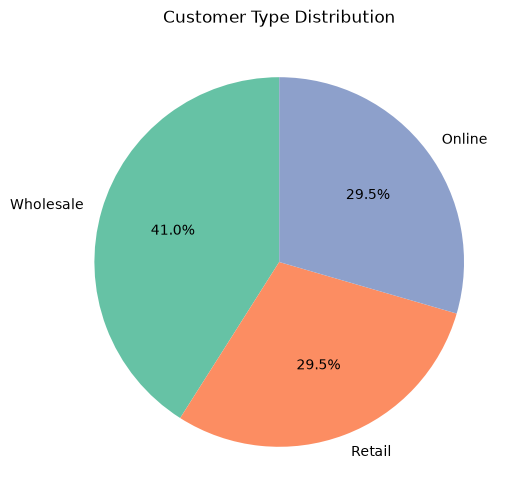

In [203]:
plt.figure(figsize=(6, 6))
plt.pie(
    counts.values,
    labels=counts.index,
    autopct="%1.1f%%",
    startangle=90,
    colors=sns.color_palette("Set2")
)
plt.title("Customer Type Distribution")

plt.show()

In [204]:
df.groupby("CustomerType")["Profit"].mean()


CustomerType
Online       438.775424
Retail       494.842203
Wholesale    441.341829
Name: Profit, dtype: float64

In [205]:
print(df.groupby("CustomerType")["Sales"].describe())
print()
print(df.groupby("CustomerType")["Profit"].describe())

              count         mean          std    min      25%     50%     75%  \
CustomerType                                                                    
Online         59.0  2432.864407  1549.881758   56.0  1105.50  2369.0  4042.5   
Retail         59.0  2845.728814  1517.818339  279.0  1485.50  3023.0  4320.0   
Wholesale      82.0  2463.426829  1513.734855  100.0  1103.75  2381.0  3731.5   

                 max  
CustomerType          
Online        4852.0  
Retail        4998.0  
Wholesale     4961.0  

              count        mean         std    min      25%      50%      75%  \
CustomerType                                                                    
Online         59.0  438.775424  338.644723   9.82  137.135  399.440  668.385   
Retail         59.0  494.842203  353.459977  54.12  222.420  363.610  763.410   
Wholesale      82.0  441.341829  349.944976   5.13  156.935  374.915  625.360   

                  max  
CustomerType           
Online        1377.04  


In [206]:
print(pd.crosstab(df["ProductCategory"], df["CustomerType"]))

CustomerType        Online  Retail  Wholesale
ProductCategory                              
Beverages               16      14         22
Clothing                11       9         18
Electronics             12      12         12
Food                     9      12         13
Household Products      11      12         17


In [207]:
print(pd.crosstab(df["Region"], df["CustomerType"]))

CustomerType  Online  Retail  Wholesale
Region                                 
Central           14      15         17
Eastern           17      17         26
Northern          18      12         15
Western           10      15         24


In [208]:
df = df.drop("TransactionID", axis=1)
df.tail()

,Date,Region,ProductCategory,CustomerType,Sales,Profit
195,2026-05-17,Eastern,Household Products,Online,4360,361.90
196,2026-05-23,Eastern,Clothing,Wholesale,2138,143.04
197,2026-01-12,Northern,Clothing,Online,3530,744.03
198,2026-06-14,Western,Household Products,Retail,3470,792.78
199,2026-03-18,Western,Beverages,Retail,4063,1013.02


In [209]:
#Feature Engineering
df_copy = df.copy()

#Covert date to datetime
df_copy['Date'] = pd.to_datetime(df_copy['Date'])
df_copy['Week'] = df_copy['Date'].dt.weekday
df_copy['Month'] = df_copy['Date'].dt.month
df_copy['Day'] = df_copy['Date'].dt.day

In [210]:
df_copy = df_copy.drop("Date", axis=1)
df_copy.head()

,Region,ProductCategory,CustomerType,Sales,Profit,Week,Month,Day
0,Eastern,Electronics,Wholesale,4924,359.44,1,6,16
1,Central,Electronics,Retail,3283,944.32,3,2,12
2,Northern,Food,Online,4049,967.10,6,3,1
3,Western,Household Products,Online,4331,434.57,2,6,3
4,Western,Household Products,Retail,3283,340.48,2,1,21


In [ ]:
#Label Encoding
label_encoder = {}
le = LabelEncoder()
df_copy["CustomerType_Encoded"] = le.fit_transform(
    df_copy["CustomerType"]
)
print(dict(zip(le.classes_,
               le.transform(le.classes_))))

{'Online': np.int64(0), 'Retail': np.int64(1), 'Wholesale': np.int64(2)}


In [ ]:
#One hot encoding
df_copy = pd.get_dummies(
    df_copy,
    columns=["Region", "ProductCategory"],
    drop_first=True
)

In [214]:
#Dropping the original categorical columns after encoding
df_copy.drop(['Region', 'ProductCategory', 'CustomerType'], axis=1, inplace=True, errors='ignore')
print("Columns after dropping:", df_copy.columns)
df_copy.head()

Columns after dropping: Index(['Sales', 'Profit', 'Week', 'Month', 'Day', 'CustomerType_Encoded',
       'Region_Eastern', 'Region_Northern', 'Region_Western',
       'ProductCategory_Clothing', 'ProductCategory_Electronics',
       'ProductCategory_Food', 'ProductCategory_Household Products'],
      dtype='str')


,Sales,Profit,Week,Month,Day,CustomerType_Encoded,Region_Eastern,Region_Northern,Region_Western,ProductCategory_Clothing,ProductCategory_Electronics,ProductCategory_Food,ProductCategory_Household Products
0,4924,359.44,1,6,16,2,True,False,False,False,True,False,False
1,3283,944.32,3,2,12,1,False,False,False,False,True,False,False
2,4049,967.10,6,3,1,0,False,True,False,False,False,True,False
3,4331,434.57,2,6,3,0,False,False,True,False,False,False,True
4,3283,340.48,2,1,21,1,False,False,True,False,False,False,True


In [215]:
#Splitting into X and y
X = df_copy.drop("CustomerType_Encoded", axis=1)
y = df_copy["CustomerType_Encoded"]

In [216]:
#Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=72
)

In [217]:
#Scaling for the Logistic Regression model
scaler = StandardScaler()
numeric_columns = ["Sales","Profit","Month","Day","Week"]
X_train[numeric_columns] = scaler.fit_transform(X_train[numeric_columns])
X_test[numeric_columns] = scaler.transform(X_test[numeric_columns])


In [ ]:
#Training
classification_models = {
    'LogisticRegression': LogisticRegression(max_iter=2000),
    'DecisionTreeClassifier': DecisionTreeClassifier(random_state=42),
    'RandomForestClassifier': RandomForestClassifier(n_estimators=200,random_state=42),    
}

classification_results = {}

print("Training classification models...")
for name, model in classification_models.items():
    model.fit(X_train, y_train)
    
    y_pred = model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    class_report = classification_report(y_test, y_pred)
    confusion_mx = confusion_matrix(y_test, y_pred)
    
    print(f"Model: {name}")
    print(pd.Series(y_pred).value_counts())
    print(f"Predictions for {name}: {y_pred[:5]}")  # Display first 5 predictions
    print(f"Actual values: {y_test.values[:5]}")  # Display first 5 actual values
    print(f"Accuracy: {accuracy}")
    print(class_report)
    print(confusion_mx)
    
    print("-" * 50)
    
    classification_results[name] = {
        'model': model,
        'accuracy': accuracy,
        'classification report': class_report,
        'confusion matrix': confusion_mx,
        'predicted': y_pred,
    }

Training classification models...
Model: LogisticRegression
2    26
1     7
0     7
Name: count, dtype: int64
Predictions for LogisticRegression: [2 2 2 1 2]
Actual values: [1 1 1 0 2]
Accuracy: 0.3
              precision    recall  f1-score   support

           0       0.29      0.18      0.22        11
           1       0.14      0.08      0.10        13
           2       0.35      0.56      0.43        16

    accuracy                           0.30        40
   macro avg       0.26      0.27      0.25        40
weighted avg       0.26      0.30      0.27        40

[[ 2  3  6]
 [ 1  1 11]
 [ 4  3  9]]
--------------------------------------------------
Model: DecisionTreeClassifier
0    18
2    13
1     9
Name: count, dtype: int64
Predictions for DecisionTreeClassifier: [0 2 0 2 0]
Actual values: [1 1 1 0 2]
Accuracy: 0.375
              precision    recall  f1-score   support

           0       0.39      0.64      0.48        11
           1       0.33      0.23      0.27     

In [221]:
#With Cross Validation
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=72
)

for name, model in classification_models.items():

    scores = cross_val_score(
        model,
        X,
        y,
        cv=cv,
        scoring="accuracy"
    )

    print(f"\n{name}")
    print("Fold Accuracies:", scores)
    print(f"Mean Accuracy: {scores.mean():.3f}")
    print(f"Standard Deviation: {scores.std():.3f}")


c:\Users\hp\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 2000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=2000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
c:\Users\hp\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 2000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=2000).
You might also want to scale the data as shown in:
    https://scikit-


LogisticRegression
Fold Accuracies: [0.375 0.375 0.25  0.375 0.35 ]
Mean Accuracy: 0.345
Standard Deviation: 0.048

DecisionTreeClassifier
Fold Accuracies: [0.375 0.4   0.3   0.25  0.325]
Mean Accuracy: 0.330
Standard Deviation: 0.053

RandomForestClassifier
Fold Accuracies: [0.425 0.275 0.275 0.275 0.375]
Mean Accuracy: 0.325
Standard Deviation: 0.063
